# Exercise 14: Mediation

This homework assignment is designed to give you practice with mediation. You won't need to load in any data for this homework -- we'll simulate data instead.

---
## 1. Simulating data (3 points)


In this homework, we're going to simulate the relationship between age, word reading experience, and reading comprehension skill. Older children tend to be better at reading comprehension tasks, but this isn't just an inherent part of getting older. It's a combination of gaining more experience with reading, oral language skills, and executive functions development. In this homework, though, we're going to simplify this relationship down to a direct effect of age on reading comprehension (since improvements in oral language skills and executive functions are more guaranteed as children age than reading practice is), and a mediation of word reading experience.

In graphical form:
![picture](https://drive.google.com/uc?id=1wdm9xuiJhBJor99-9GnicO2_rzkGWtfN)

Writing the relationship out formally:

$$x = \beta_{xa} a + \beta_{x0} + \epsilon_{x}$$

$$c = \beta_{ca} a + \beta_{cx} x + \beta_{c0} + \epsilon_c$$



$c$ is reading comprehension, $x$ is word reading experience, and $a$ is age. $\beta_{c0}$ and $\beta_{x0}$ are intercept terms for their respective formulas, and $\epsilon_{c}$ and $\epsilon_{x}$ are gaussian noise terms. We'll start by writing a function, `simulate_data`, that can simulate this relationship. The input values are set and the function structure is provided below. Complete the function such that it takes in those input variables and generates $age$, $x$, and $c$ values. Use `runif()` to generate ages. Use `rnorm()` to generate the noise terms.

In [21]:
sample_size = 100 # How many children in data set?
age_lo = 80     # minimum age, in months
age_hi = 200    # maximum age, in months
beta_xa = 0.5   # amount by which experience changes for increase of one month in age
beta_x0 = -5    # amount of experience when age = 0 (not interpretable, since minimum age for this data is 80 months)
sd_x = 50       # standard dev of gaussian noise term, epsilon_x
beta_ca = 0.8   # amount that comprehension score improves for every increase of one unit in age
beta_cx = 3     # amount that comprehension score improves for every increase of one unit in reading experience
beta_c0 = 10    # comprehension score when reading experience is 0.
sd_c = 85      # standard dev of gaussian noise term, epsilon_c

simulate_data <- function(sample_size, age_lo, age_hi, beta_xa,
                          beta_x0, sd_x, beta_ca, beta_cx, beta_c0, sd_c) {
    
                noise_c = rnorm(sample_size, mean = 0, sd = sd_c) #reading comprehension noise term
                noise_x = rnorm(sample_size, mean = 0, sd = sd_x) #word reading exp noise term

                age = runif(sample_size, min = age_lo, max = age_hi) #generate n random values from specified range

                x = beta_xa*age + beta_x0 + noise_x
                c = beta_ca*age + beta_cx*x + beta_c0 + noise_c  
                
                return(data.frame(age = age, reading_exp = x, reading_comp = c)) #I used GPT for this line for the right syntax to get the returned variables as a dataframe
}

dat <- simulate_data(sample_size, age_lo, age_hi, beta_xa, beta_x0, sd_x, beta_ca, beta_cx, beta_c0, sd_c)
head(dat)
dim(dat)

,age,reading_exp,reading_comp
,<dbl>,<dbl>,<dbl>
1,104.9290,29.97120,88.00924
2,188.8953,89.84477,474.81320
3,133.4581,93.92540,523.18295
4,161.4058,60.79465,174.75265
5,129.4574,53.99317,261.45037
6,175.6686,97.47057,424.40987


[1] 100   3

---
## 2. Visualizing Data (2 point)

Load the `tidyverse` library.

In [24]:
library(tidyverse)


── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


a) Create a scatter plot showing the relationship between age and reading comprehension.

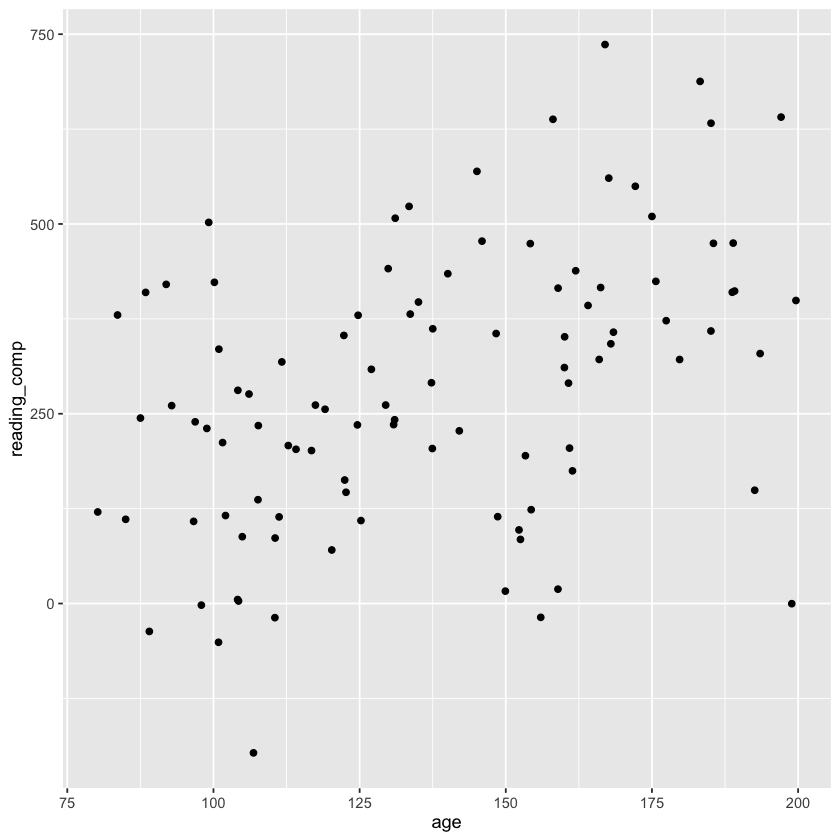

In [27]:
library(ggplot2)
ggplot(dat,aes(x=age,y=reading_comp)) + geom_point()

b) Create a scatter plot showing the relationship among age, reading experience, and reading comprehension.

*Hint: You can represent reading comprehension using an additional visual dimension such as the color or size of the points.*

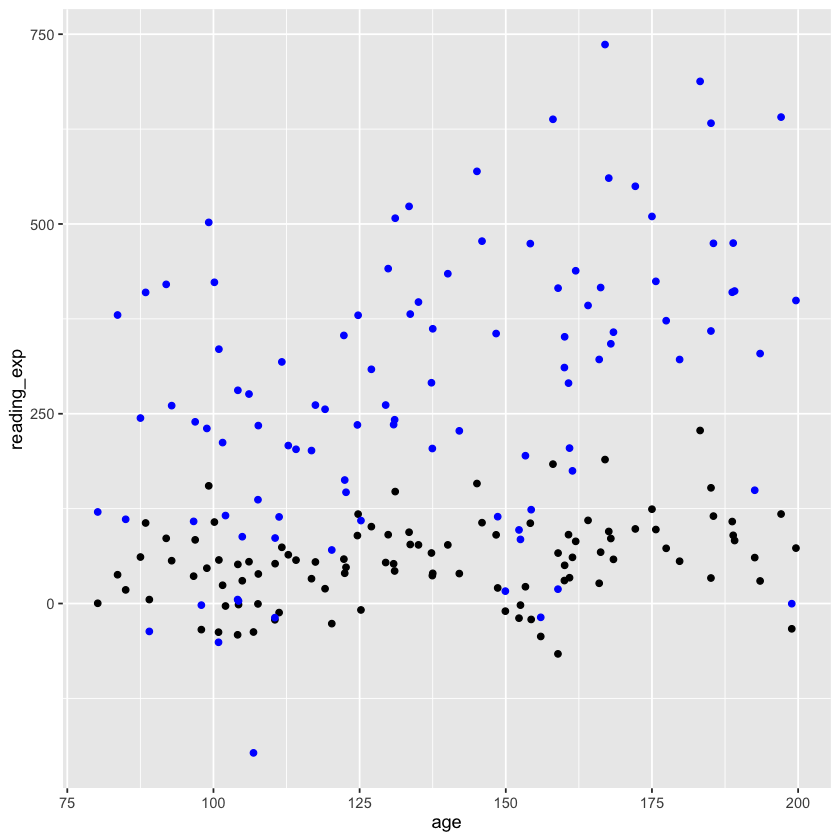

In [30]:
ggplot(dat, aes(x=age)) + 
    geom_point(aes(y=reading_exp), color = "black") + 
    geom_point(aes(y=reading_comp), color = "blue")


---
## 3. Mediation Analysis (4 points)

Load the `mediation` library.

In [31]:
install.packages("mediation")
library(mediation)

also installing the dependencies ‘checkmate’, ‘htmlwidgets’, ‘zoo’, ‘gridExtra’, ‘htmlTable’, ‘colorspace’, ‘Formula’, ‘mvtnorm’, ‘sandwich’, ‘lpSolve’, ‘Hmisc’





The downloaded binary packages are in
	/var/folders/bv/wcq8jkrd26sg1y3bg18qjglh0000gp/T//Rtmpt7nXsk/downloaded_packages


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: mvtnorm

Loading required package: sandwich

mediation: Causal Mediation Analysis
Version: 4.5.1




Use the `mediate` function to determine whether `x` mediates the relationship between `age` and `c`. Use `summary()` to print the model results. *Hint: see the mediation and moderation tutorial.*

In [33]:
fitM <- lm(reading_exp ~ age, data=dat) #Step 1: IV on M
fitY <- lm(reading_comp ~ age + reading_exp, data=dat) #Step 2: IV and M on DV
summary(fitM)
summary(fitY)
fitMed <- mediate(fitM, fitY, treat="age", mediator="reading_exp")
summary(fitMed)



Call:
lm(formula = reading_exp ~ age, data = dat)

Residuals:
    Min      1Q  Median      3Q     Max 
-133.24  -29.13    0.60   26.86  148.92 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)   
(Intercept) -12.3726    22.7756  -0.543   0.5882   
age           0.4988     0.1614   3.091   0.0026 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 52.11 on 98 degrees of freedom
Multiple R-squared:  0.08881,	Adjusted R-squared:  0.07951 
F-statistic: 9.551 on 1 and 98 DF,  p-value: 0.002601



Call:
lm(formula = reading_comp ~ age + reading_exp, data = dat)

Residuals:
     Min       1Q   Median       3Q      Max 
-202.085  -49.890    3.968   45.915  202.287 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -14.0063    33.0091  -0.424    0.672    
age           1.0024     0.2447   4.097 8.69e-05 ***
reading_exp   2.8478     0.1462  19.481  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 75.41 on 97 degrees of freedom
Multiple R-squared:  0.8339,	Adjusted R-squared:  0.8305 
F-statistic: 243.6 on 2 and 97 DF,  p-value: < 2.2e-16



Causal Mediation Analysis 

Quasi-Bayesian Confidence Intervals

               Estimate 95% CI Lower 95% CI Upper p-value    
ACME            1.42064      0.53498      2.31398   0.002 ** 
ADE             1.00617      0.54523      1.44933  <2e-16 ***
Total Effect    2.42682      1.40314      3.40971  <2e-16 ***
Prop. Mediated  0.58385      0.33778      0.75867   0.002 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Sample Size Used: 100 


Simulations: 1000 


---
## 5. Reflection (1 point)
Is there a significant direct or indirect effect? What do you conclude based on the analyses above?

> It seems like there is both a direct and indirect effect, based on significant ADE and ACME scores. This is corroborated by the fact that in the linear model analyses, including reading experience as a predictor did NOT make age an insignificant predictor. My interpretation is that age affects reading comprehension both directly and indirectly through reading experience, although it seems like indirect effects have slightly more "sway" than direct effects (as indicated by the measure of Proportion Mediated being 0.58). 

**DUE:** 11:59pm EST, March 26, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*